#  Нормализация данных, кроссвалидация и решетчатый поиск

На этом уроке мы поговорим о некоторых специальных вещах, которые нужно знать специалисту в machine learning. Прежде всего, мы посмотрим, почему нужно *масштабировать* данные тренировочного и тестового наборов, используя характеристики вычисленные только на основе тренировочного набора данных. Далее обсудим виды *перекрестной проверки*, *решетчатого поиска* и их комбинации для поиска оптимальных параметров модели.

## 1. Масштабирование обучающего и тестового наборов с использованием характеристик, вычисленных по тренировочному набору

При нормализации данных важно преобразовать обучающий и тестовый наборы правильно. Следующий пример  показывает, что произошло бы, если бы для нормализации тестового набора мы использовали характеристики, вычисленные по нему:

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt

# создаем синтетические данные
X, _ = make_blobs(n_samples=50, centers=5, random_state=4, cluster_std=2)

# разбиваем их на обучающий и тестовый наборы
X_train, X_test = train_test_split(X, random_state=5, test_size=.1)

Визуализируем точки обучающего и тестового набора. Точки обучающего набора показаны кружками, тестового - треугольниками.

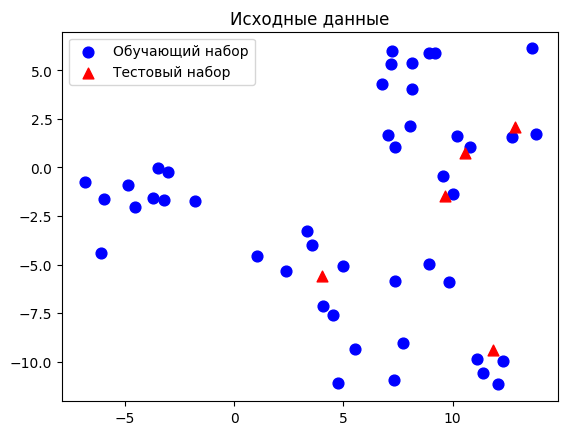

In [ ]:
plt.scatter(X_train[:, 0], X_train[:, 1], color='b', label="Обучающий набор", s=60)
plt.scatter(X_test[:, 0], X_test[:, 1], marker='^', color='r', label="Тестовый набор", s=60)
plt.title("Исходные данные")
plt.legend(loc='upper left')

Масштабируем данные с помощью MinMaxScaler, используя только обучающий набор,т.е. min и max значения каждого признака вычисляются по точкам обучающего набора.
Здесь мы вызвали метод fit для обучающего набора, а затем вызвали
метод transform для обучающего и тестового наборов. Как видите, набор
данных на втором графике идентичен набору, приведенному на первом
графике, изменились лишь метки осей. Теперь все признаки принимают
значения в диапазоне от 0 до 1. Кроме того, видно, что минимальные и
максимальные значения признаков в тестовом наборе (треугольники) не
равны 0 и 1.

Text(0.5, 1.0, 'Масштабированные данные')

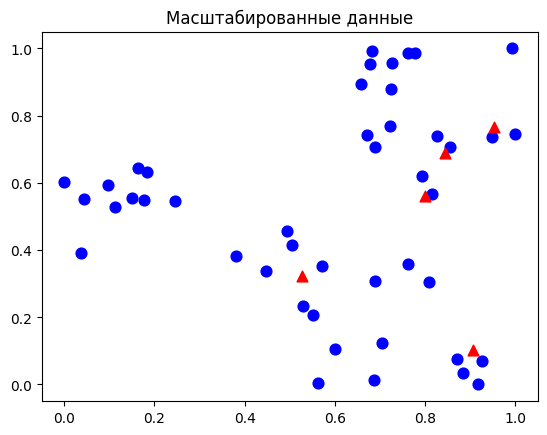

In [ ]:
scaler = MinMaxScaler() # масштабируем данные с помощью MinMaxScaler
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
# визуализируем правильно масштабированные данные
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], color='b', label="Обучающий набор", s=60)
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], marker='^',color='r', label="Тестовый набор", s=60)
plt.title("Масштабированные данные")

Масштабируем теперь тестовый набор по значениям min, max, вычисленные по нему.

Text(0.5, 1.0, 'Неправильно масштабированные данные')

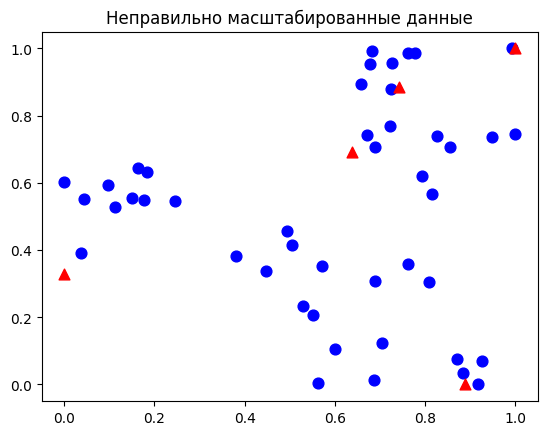

In [ ]:
# масштабируем тестовый набор отдельно
# чтобы в тестовом наборе min значение каждого признака было равно 0
# а max значение каждого признака равнялось 1

''' НЕ ДЕЛАЙТЕ ТАК! Только в ознакомительных целях.'''

test_scaler = MinMaxScaler()
test_scaler.fit(X_test)
X_test_scaled_badly = test_scaler.transform(X_test)

# визуализируем неправильно масштабированные данные
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], color='b', label="Обучающий набор", s=60)
plt.scatter(X_test_scaled_badly[:, 0], X_test_scaled_badly[:, 1], marker='^', color='r', label="Тестовый набор", s=60)
plt.title("Неправильно масштабированные данные")

График показывает, что произойдет, если мы отмасштабируем
обучающий и тестовый наборы по отдельности. В этом случае
минимальные и максимальные значения признаков в обучающем и
тестовом наборах равны 0 и 1. Но теперь набор данных выглядит иначе.
Тестовые точки причудливым образом сместились, поскольку
масштабированы по-другому. Мы изменили расположение данных
произвольным образом. Очевидно, это совсем не то, что нам нужно.

Еще один способ задуматься о неправильности этих действий
заключается в том, чтобы представить тестовый набор в виде одной точки.
Не существует способа правильно масштабировать единственную точку
данных, чтобы с помощью MinMaxScaler получить значения минимума и
максимума. Однако размер тестового набора не должен влиять на
обработку данных.

## 2. Проверка качества модели. Кросс-валидация (Cross Validation, CV) и Leave-One-Out CV


Главная задача обучаемых алгоритмов – их способность обобщаться, то есть хорошо работать на новых данных. Для проверки качества построенной модели работы чаще всего используются 2 способов:

1) **отложенная выборка** (held-out/hold-out set). При таком подходе мы оставляем какую-то долю обучающей выборки (чаще 20%), обучаем модель на остальных данных (80% исходной выборки) и считаем некоторую метрику качества модели (например, долю правильных ответов в задаче классификации) на отложенной выборке.
Функция __train_test_split()__  выполняет такое случайное  разбиение  данных.

2) **кросс-валидация** (K-fold cross-validation, скользящий или перекрестный контроль).

Первый способ нам уже хорошо знаком. Остановимся на втором способе.

<center><img src= "https://hsto.org/files/b1d/706/e6c/b1d706e6c9df49c297b6152878a2d03f.png" width=800></center>

При кросс-валидации по K папкам модель обучается К раз на разных подвыборках исходной выборки (белый цвет), а проверяется на одной подвыборке (каждый раз на разной, оранжевый цвет).

В результате получаются К оценок качества модели, которые обычно усредняются, выдавая среднюю оценку качества классификации/регрессии на кросс-валидации.

Кросс-валидация дает лучшую по сравнению с отложенной выборкой оценку качества модели на новых данных. Но кросс-валидация вычислительно дорогостоящая, если данных много. Теперь  мы  обучаем  К  моделей  вместо  одной
модели,  поэтому перекрестная  проверка    будет  выполняться  примерно  в  К  раз медленнее.

В частном случае, когда K равно объему выборки, т.е. для тестирования каждый раз оставляется ровно один образец, метод K-fold cross validation превращается в метод __Leave-One-Out__ (исключение по одному).

Давайте посмотрим на пример использования кросс-валидации на примере данных "Ирисы Фишера".

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import warnings
warnings.filterwarnings("ignore")

iris = load_iris()
X = iris.data
Y = iris.target

knn = KNeighborsClassifier()

Теперь воспользуемся функцией cross_val_score. kNN будет запущен 5 раз и мы получим 5 значений ошибок этих моделей.

In [ ]:
print("Значения правильности перекрестной проверки:\n{}".format(cross_val_score(knn , X, Y, cv=5)))

Значения правильности перекрестной проверки:
[0.96666667 1.         0.93333333 0.96666667 1.        ]


Как видно, они заметно отличаются, в качестве оценки производительности модели можно принять среднюю из них. Можно пойти дальше и, воспользовавшись методом LOO, получить еще более реальную ошибку модели.

In [ ]:
from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()
scores = cross_val_score(knn, X, Y, cv=loo)
print("Количество итераций: ", len(scores))
print("Средняя правильность kNN: {:.3f}".format(scores.mean()))

Количество итераций:  150
Средняя правильность kNN: 0.967


Самый интересный вопрос в связи со всем происходящим, заключается в следующем. Мы как-то очень хорошо оценили точность модели, построенной с помощью метода ,ближайших соседей, но какой? Где сама модель? Их 5 штук в первом случае и 150 во втором.

Общепринятой практикой при использовании перекрестной проверки является выявление средней ошибки (как сделано выше) нескольких моделей, и дальнейшего обучения на **ВСЕМ** наборе данных. Когда мы все данные использовали для обучения, модель (наверное) получилась наилучшей возможной, а ошибка ее уже оценена ранее.

Давайте для интереса, посмотрим, какую ошибку дадут другие известные нам методы.

In [ ]:
log = LogisticRegression(max_iter=10000)
svm = SVC()

loo = LeaveOneOut()
scores = cross_val_score(log, X, Y, cv=loo)
print("Количество итераций: ", len(scores))
print("Средняя правильность LogisticRegression: {:.3f}".format(scores.mean()))

Количество итераций:  150
Средняя правильность LogisticRegression: 0.967


In [ ]:
loo = LeaveOneOut()
scores = cross_val_score(svm, X, Y, cv=loo)
print("Количество итераций: ", len(scores))
print("Средняя правильность SVM: {:.3f}".format(scores.mean()))

Количество итераций:  150
Средняя правильность SVM: 0.967


Отметим, что мы использовали методы без настройки параметров.

## 3. Решетчатый поиск (Grid Search). Тестовый, тренировочный и валидационный наборы данных

Поиск оптимальных значений ключевых параметров
модели, то есть значений, которые дают наилучшую обобщающую
способность, является сложной задачей, но она обязательна почти для
всех моделей и наборов данных.

Поскольку поиск оптимальных значений
параметров является общераспространенной задачей, библиотека
scikit-learn предлагает стандартные методы, позволяющие решить ее.
Наиболее часто используемый метод – это **решетчатый поиск** (grid
search), который по сути является попыткой перебрать все возможные
комбинации интересующих параметров.

Рассмотрим применение метода нелинейного SVM с ядром RBF
(радиальной базисной функцией), реализованного в классе SVC. В нелинейном методе опорных векторов есть два
важных параметра: ширина ядра **gamma** и параметр регуляризации **C**.

Допустим, мы хотим попробовать значения 0.001, 0.01, 0.1, 1, 10 и 100
для параметров gamma и С. Поскольку нам
нужно попробовать шесть различных настроек для C и gamma, получается
36 комбинаций параметров в целом. Все возможные комбинации
формируют таблицу (которую еще называют решеткой или сеткой)
настроек параметров для SVM, как показано ниже:

<center><img src= "https://i.ibb.co/9V1wb9j/te.png" width=500></center>

Мы можем реализовать простой решетчатый поиск с помощью
вложенных циклов **for** по двум параметрам, обучая и оценивая
классификатор для каждой комбинации.

Давайте возьмем встроенный в sklearn набор данных для задачи бинарной классификации опухоли и для начала посмотрим, что дает метод опорных векторов без какого-либо подбора параметров.

In [ ]:
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)
print("Размер обучающего набора: {} размер тестового набора: {}".format(X_train.shape[0], X_test.shape[0]))

svm = SVC()
svm.fit(X_train, y_train)

# оцениваем качество SVC на тестовом наборе
svm.score(X_test, y_test)

Размер обучающего набора: 426 размер тестового набора: 143


0.9370629370629371

Теперь переберем разные комбинации параметров C и gamma.

In [ ]:
# реализация наивного решетчатого поиска

best_score = 0
for gamma in [1e-07, 1e-06, 1e-05, 1e-04, 1e-03, 0.01, 0.1, 1]:
    for C in [0.1, 1, 10, 50, 100, 200, 300, 400, 500]:
        # для каждой комбинации параметров обучаем SVC
        svm = SVC(gamma=gamma, C=C)
        svm.fit(X_train, y_train)

        # оцениваем качество SVC на тестовом наборе
        score = svm.score(X_test, y_test)
        # если получаем наилучшее значение правильности, сохраняем значение и параметры
        if score > best_score:
            best_score = score
            best_parameters = {'C': C, 'gamma': gamma}

print("Наилучшее значение правильности: {:.3f}".format(best_score))
print("Наилучшие значения параметров: {}".format(best_parameters))


Наилучшее значение правильности: 0.979
Наилучшие значения параметров: {'C': 200, 'gamma': 1e-05}


Получив такой результат, мы могли бы поддаться искушению и заявить,
что нашли модель, которая дает 98%-ную правильность на нашем наборе
данных. Однако это заявление может быть чрезмерно оптимистичным
(или просто неверным) по следующей причине: мы перебрали множество
значений параметров и выбрали ту комбинацию значений, которая дает
наилучшую правильность на тестовом наборе, но это вовсе не означает,
что на новых данных мы получим такое же значение правильности.

Поскольку мы использовали тестовый набор для настройки параметров,
мы больше не можем использовать его для оценки качества модели. Это
та же самая причина, по которой нам изначально нужно разбивать
данные на обучающий и тестовый наборы. Теперь для оценки качества
модели нам необходим независимый набор данных, то есть набор,
который не использовался для построения модели и настройки ее
параметров.

Один из способов решения этой проблемы заключается в том, чтобы
разбить данные еще раз, таким образом, мы получаем три набора:
обучающий набор для построения модели, проверочный
(валидационный) набор для выбора параметров модели, а также
тестовый набор для оценки качества работы выбранных параметров.

После выбора наилучших параметров с помощью проверочного
набора, мы можем заново построить модель, используя
найденные настройки, но теперь на основе объединенных обучающих и
проверочных данных. Таким образом, мы можем использовать для
построения модели максимально возможное количество данных. Это
приводит к следующему программному коду:

In [ ]:
# разбиваем данные на обучающий+проверочный набор и тестовый набор
X_trainval, X_test, y_trainval, y_test = train_test_split(cancer.data, cancer.target, random_state=0)

# разбиваем обучающий+проверочный набор на обучающий и проверочный наборы
X_train, X_valid, y_train, y_valid = train_test_split(X_trainval, y_trainval, random_state=0)

print("Размер обучающего набора: {}, размер проверочного набора: {}, размер тестового набора:"
" {}\n".format(X_train.shape[0], X_valid.shape[0], X_test.shape[0]))

best_score = 0
for gamma in [1e-07, 1e-06, 1e-05, 1e-04, 1e-03, 0.01, 0.1, 1]:
    for C in [0.1, 1, 10, 50, 100, 200, 300, 400, 500]:

        # для каждой комбинации параметров обучаем SVC
        svm = SVC(gamma=gamma, C=C)
        svm.fit(X_train, y_train)

        # оцениваем качество SVC на валидационном наборе
        score = svm.score(X_valid, y_valid)

        # если получаем наилучшее значение правильности, сохраняем значение и параметры
        if score > best_score:
            best_score = score
            best_parameters = {'C': C, 'gamma': gamma}

# заново строим модель на наборе, полученном в результате объединения обучающих
# и проверочных данных, оцениваем качество модели на тестовом наборе
svm = SVC(**best_parameters)
svm.fit(X_trainval, y_trainval)
test_score = svm.score(X_test, y_test)
print("Лучшее значение правильности на проверочном наборе: {:.3f}".format(best_score))
print("Наилучшие значения параметров: ", best_parameters)
print("Правильность на тестовом наборе с наилучшими параметрами: {:.3f}".format(test_score))

Размер обучающего набора: 319, размер проверочного набора: 107, размер тестового набора: 143

Лучшее значение правильности на проверочном наборе: 0.944
Наилучшие значения параметров:  {'C': 400, 'gamma': 1e-06}
Правильность на тестовом наборе с наилучшими параметрами: 0.944


Значение правильности на тестовом наборе, которое
показывает реальную обобщающую способность – стало ниже, 94,4%.
Таким образом, мы можем утверждать, что правильность классификации
новых данных составляет 94,4%, а не 98%, как мы думали ранее!

Наличие различий между обучающим, проверочным и тестовым
наборами имеет принципиально важное значение для применения
методов машинного обучения на практике. Любой выбор, сделанный,
исходя из правильности на тестовом наборе, «сливает» модели
информацию тестового набора. Поэтому важно иметь отдельный
тестовый набор, который используется лишь для итоговой оценки.
Строго говоря, оценка качества моделей и выбор
наилучшей из них с помощью тестового набора, использующегося для
отбора параметров, приведет к чрезмерно оптимистичной оценке
правильности модели.

## 4. GridSearch+CV



Хотя только что рассмотренный нами метод разбиения данных на
обучающий, проверочный и тестовый наборы является вполне рабочим
и относительно широко используемым, он весьма чувствителен к
правильности разбиения данных. Взглянув на вывод, приведенный для
предыдущего фрагмента программного кода, мы видим, что решетчатый поиск
выбрал в качестве лучших параметров 'C': 200, 'gamma': 1e-05, тогда
как вывод, приведенный для предыдущего программного кода,
сообщает нам, что наилучшими параметрами являются 'C': 400,
'gamma': 1e-06.

Для лучшей оценки обобщающей способности вместо
одного разбиения данных на обучающий и проверочный наборы мы
можем воспользоваться перекрестной проверкой. Теперь качество
модели оценивается для каждой комбинации параметров по всем
разбиениям перекрестной проверки. Этот метод можно реализовать с
помощью следующего программного кода:

In [ ]:
import numpy as np
for gamma in [1e-07, 1e-06, 1e-05, 1e-04, 1e-03, 0.01, 0.1, 1]:
    for C in [0.1, 1, 10, 50, 100, 200, 300, 400, 500]:

        # для каждой комбинации параметров,
        # обучаем SVC
        svm = SVC(gamma=gamma, C=C)

        # выполняем перекрестную проверку
        scores = cross_val_score(svm, X_trainval, y_trainval, cv=5)

        # вычисляем среднюю правильность перекрестной проверки
        score = np.mean(scores)

        # если получаем лучшее значение правильности, сохраняем значение и параметры
        if score > best_score:
            best_score = score
            best_parameters = {'C': C, 'gamma': gamma}

# заново строим модель на наборе, полученном в результате
# объединения обучающих и проверочных данных
svm = SVC(**best_parameters)
svm.fit(X_trainval, y_trainval)
test_score = svm.score(X_test, y_test)
print("Лучшее значение правильности на проверочном наборе: {:.3f}".format(best_score))
print("Наилучшие значения параметров: ", best_parameters)
print("Правильность на тестовом наборе с наилучшими параметрами: {:.3f}".format(test_score))

Лучшее значение правильности на проверочном наборе: 0.955
Наилучшие значения параметров:  {'C': 300, 'gamma': 1e-06}
Правильность на тестовом наборе с наилучшими параметрами: 0.951


Чтобы c помощью пятиблочной перекрестной проверки оценить
правильность SVM для конкретной комбинации значений C и gamma, нам
необходимо обучить 36*5=180 моделей. Как вы понимаете, основным
недостатком использования перекрестной проверки является время,
которое требуется для обучения всех этих моделей.

Выбрав параметры с помощью перекрестной проверки, мы
фактически нашли модель, которая достигает правильности 95,1% на
тестовом наборе. Главный момент здесь в том, что мы не использовали
тестовый набор для отбора параметров.